# Captcha Dataset V2 - Exploratory Data Analysis

## Setup

Run the cell below **once** to install all required dependencies with pinned versions for Python 3.11.

In [39]:
import sys
import subprocess

REQUIRED = {
    "pandas": "2.2.3",
    "numpy": "1.26.4",
    "matplotlib": "3.9.4",
    "seaborn": "0.13.2",
    "Pillow": "11.1.0",
    "jupyter": None,
}

def install_packages():
    pkgs = [f"{pkg}=={ver}" if ver else pkg for pkg, ver in REQUIRED.items()]
    cmd = [sys.executable, "-m", "pip", "install"] + pkgs
    subprocess.check_call(cmd)
    print("\nAll packages installed successfully.")

install_packages()


All packages installed successfully.


## Imports & Path Setup

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

BASE_DIR = Path.cwd().resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATASET_PATH = BASE_DIR / "dataset" / "ground_truth.csv"
IMAGES_DIR = BASE_DIR / "raw" / "images"

print(f"Base dir:    {BASE_DIR}")
print(f"Dataset:     {DATASET_PATH}")
print(f"Images dir:  {IMAGES_DIR}")
print(f"Dataset exists: {DATASET_PATH.exists()}")
print(f"Images dir exists: {IMAGES_DIR.exists()}")

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid")

Base dir:    /Users/alikhan/programming/Captcha-Benchmark-Tool/V2
Dataset:     /Users/alikhan/programming/Captcha-Benchmark-Tool/V2/dataset/ground_truth.csv
Images dir:  /Users/alikhan/programming/Captcha-Benchmark-Tool/V2/raw/images
Dataset exists: True
Images dir exists: True


## 1. Load Dataset

In [41]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (1380, 2)
Columns: ['image', 'captcha_value']


,image,captcha_value
0,captcha_4921.png,Y4MGWA
1,captcha_4922.png,Y4MGWA
2,captcha_4923.png,Y4MGWA
3,captcha_4924.png,Y4MGWA
4,captcha_4925.png,A5FGKY
5,captcha_4926.png,7YGGDH
6,captcha_4927.png,DDC3NA
7,captcha_4928.png,DDC3NA
8,captcha_4929.png,WRM5B4
9,captcha_4930.png,WRM5B4


In [42]:
print(f"Total samples: {len(df)}")
print(f"Unique images: {df['image'].nunique()}")
print(f"Unique captcha values: {df['captcha_value'].nunique()}")
print(f"\nAny null values?")
print(df.isnull().sum())

Total samples: 1380
Unique images: 1380
Unique captcha values: 929

Any null values?
image            0
captcha_value    0
dtype: int64


## 2. Data Quality Checks

Verify that every image in the ground truth actually exists on disk.

In [43]:
missing_images = []
for img_name in df['image']:
    if not (IMAGES_DIR / img_name).exists():
        missing_images.append(img_name)

images_on_disk = set(os.listdir(IMAGES_DIR))
unreferenced_images = [f for f in images_on_disk if f not in set(df['image'])]

print(f"Images in CSV missing from disk: {len(missing_images)}")
if missing_images:
    print(missing_images[:10])

print(f"Images on disk not in CSV: {len(unreferenced_images)}")
if unreferenced_images:
    print(unreferenced_images[:10])

if not missing_images and not unreferenced_images:
    print("\nAll images perfectly synced between CSV and disk!")
else:
    print(f"\nNote: {len(unreferenced_images)} images on disk are not in the ground truth.")
    print("Run `python create_dataset.py` to rebuild the dataset if needed.")

Images in CSV missing from disk: 0
Images on disk not in CSV: 0

All images perfectly synced between CSV and disk!


## 3. Captcha Value Analysis

### 3.1 Captcha Length Distribution

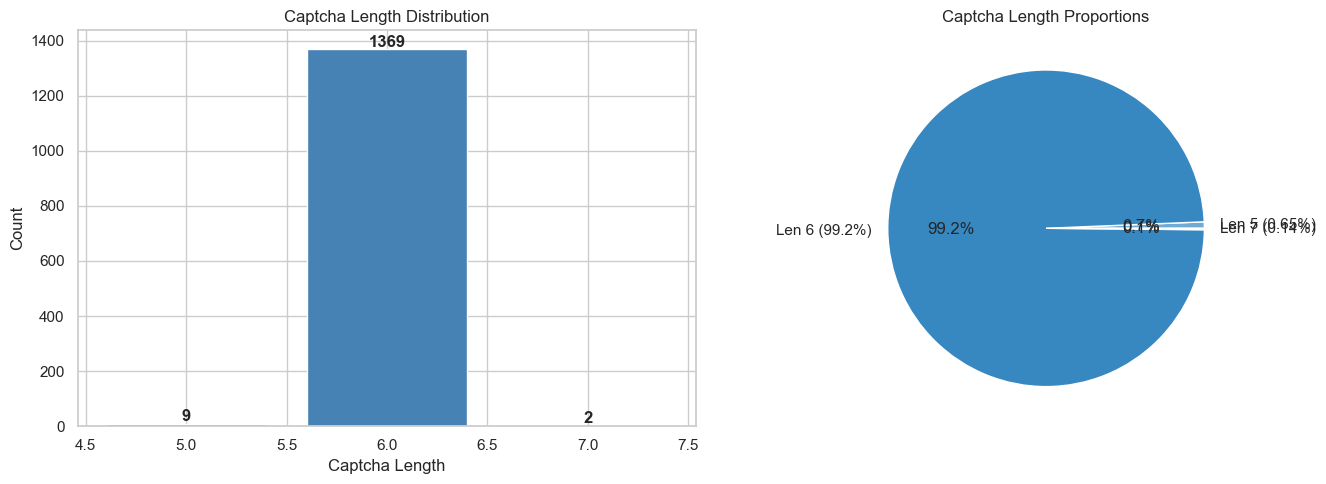


Length distribution:
  Length 5: 9 samples (0.65%)
  Length 6: 1369 samples (99.20%)
  Length 7: 2 samples (0.14%)


In [44]:
df['captcha_length'] = df['captcha_value'].str.len()

length_counts = df['captcha_length'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(length_counts.index, length_counts.values, color='steelblue')
axes[0].set_xlabel('Captcha Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Captcha Length Distribution')
for i, v in enumerate(length_counts.values):
    axes[0].text(length_counts.index[i], v + 10, str(v), ha='center', fontweight='bold')

length_pct = (length_counts / len(df) * 100).round(2)
axes[1].pie(length_counts.values, labels=[f'Len {l} ({length_pct[l]}%)' for l in length_counts.index], 
            autopct='%1.1f%%', colors=sns.color_palette('Blues_d', len(length_counts)))
axes[1].set_title('Captcha Length Proportions')

plt.tight_layout()
plt.savefig(BASE_DIR / 'dataset' / 'captcha_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLength distribution:")
for length, count in length_counts.items():
    print(f"  Length {length}: {count} samples ({count/len(df)*100:.2f}%)")

### 3.2 Character Frequency Analysis

In [45]:
all_chars = ''.join(df['captcha_value'].tolist())
char_freq = Counter(all_chars)

digits = sorted([c for c in char_freq if c.isdigit()])
letters = sorted([c for c in char_freq if c.isalpha()])

print(f"Total characters: {len(all_chars)}")
print(f"Unique characters: {len(char_freq)}")
print(f"Digits used ({len(digits)}): {', '.join(digits)}")
print(f"Letters used ({len(letters)}): {', '.join(letters)}")
print(f"\nNote: Vowels (I, O, U) and digits (0, 1, 9) are likely excluded to avoid confusion.")

Total characters: 8273
Unique characters: 28
Digits used (7): 2, 3, 4, 5, 6, 7, 8
Letters used (20): A, B, C, D, E, F, G, H, K, M, N, P, R, S, T, V, W, X, Y, Z

Note: Vowels (I, O, U) and digits (0, 1, 9) are likely excluded to avoid confusion.


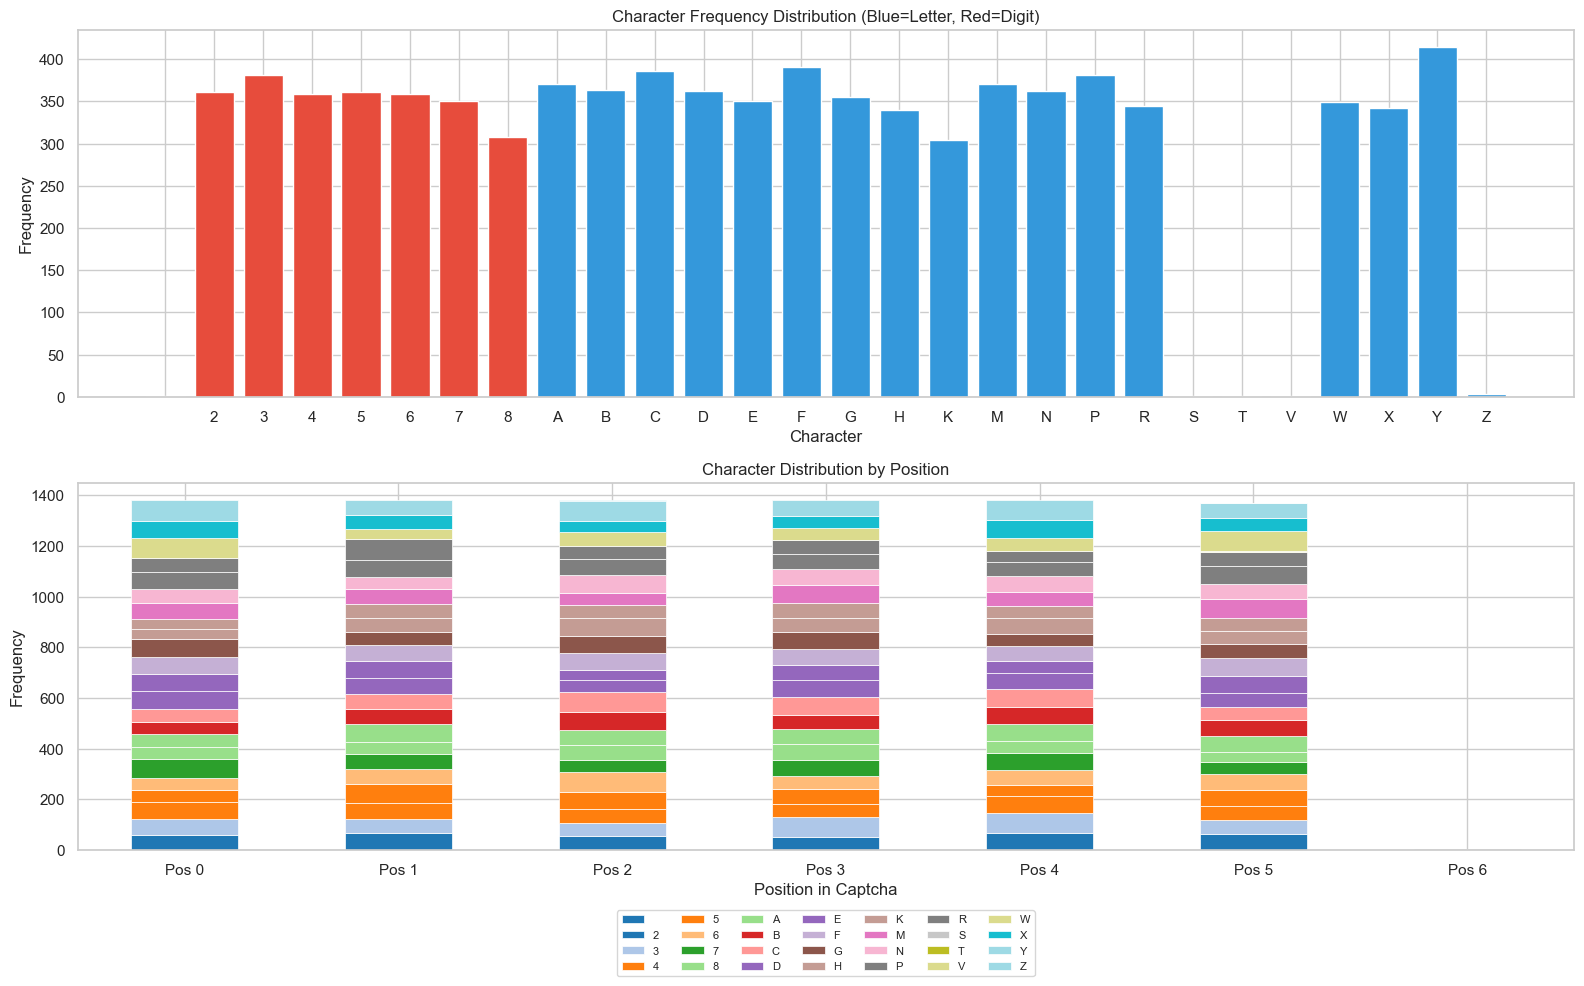

In [46]:
sorted_chars = sorted(char_freq.items(), key=lambda x: x[0])
chars = [c for c, _ in sorted_chars]
freqs = [f for _, f in sorted_chars]
colors = ['#e74c3c' if c.isdigit() else '#3498db' for c in chars]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(chars, freqs, color=colors)
axes[0].set_xlabel('Character')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Character Frequency Distribution (Blue=Letter, Red=Digit)')

# Position-wise character distribution
max_len = df['captcha_length'].max()
position_chars = {}
for pos in range(max_len):
    pos_counter = Counter()
    for val in df['captcha_value']:
        if pos < len(val):
            pos_counter[val[pos]] += 1
    position_chars[pos] = pos_counter

position_df = pd.DataFrame(position_chars).T.fillna(0)
position_df = position_df[sorted(position_df.columns)]

position_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Position in Captcha')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Character Distribution by Position')
axes[1].legend(ncol=7, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15))
axes[1].set_xticklabels([f'Pos {i}' for i in range(max_len)], rotation=0)

plt.tight_layout()
plt.savefig(BASE_DIR / 'dataset' / 'character_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Duplicate Captcha Values

In [47]:
value_counts = df['captcha_value'].value_counts()
duplicates = value_counts[value_counts > 1]

print(f"Unique captcha values: {df['captcha_value'].nunique()}")
print(f"Values appearing more than once: {len(duplicates)}")
print(f"Max occurrences of a single value: {value_counts.max()}")
print(f"\nTop 15 most frequent captcha values:")
for val, cnt in duplicates.head(15).items():
    print(f"  {val}: {cnt} times")

Unique captcha values: 929
Values appearing more than once: 239
Max occurrences of a single value: 6

Top 15 most frequent captcha values:
  GRKN6F: 6 times
  MA7EB5: 6 times
  RANCHF: 6 times
  ARM5HC: 5 times
  Y66G42: 5 times
  EYNK6X: 5 times
  X28MXH: 5 times
  MWDGY5: 5 times
  7RYK3K: 5 times
  RK6FYR: 5 times
  3D67R6: 5 times
  WXNCCF: 5 times
  BHBMXF: 5 times
  AAR433: 5 times
  7G8K6Y: 5 times


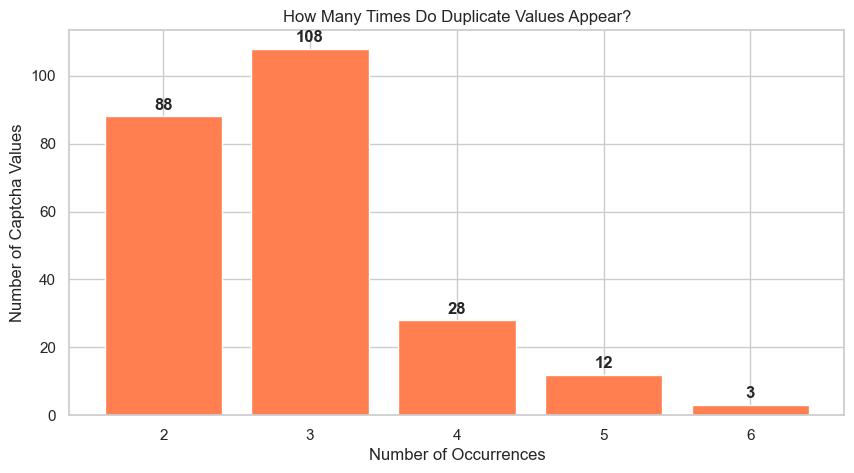

In [48]:
dupe_freq = duplicates.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(dupe_freq.index, dupe_freq.values, color='coral')
ax.set_xlabel('Number of Occurrences')
ax.set_ylabel('Number of Captcha Values')
ax.set_title('How Many Times Do Duplicate Values Appear?')
for i, (idx, val) in enumerate(zip(dupe_freq.index, dupe_freq.values)):
    ax.text(idx, val + 2, str(val), ha='center', fontweight='bold')
plt.savefig(BASE_DIR / 'dataset' / 'duplicate_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Property Analysis

In [49]:
image_sizes = []
image_modes = []
image_formats = []
file_sizes = []

for img_name in df['image']:
    path = IMAGES_DIR / img_name
    im = Image.open(path)
    image_sizes.append(im.size)
    image_modes.append(im.mode)
    image_formats.append(im.format)
    file_sizes.append(os.path.getsize(path))
    im.close()

unique_sizes = set(image_sizes)
unique_modes = set(image_modes)
unique_formats = set(image_formats)

print(f"Image dimensions: {unique_sizes}")
print(f"Color modes: {unique_modes}")
print(f"Formats: {unique_formats}")
print(f"\nFile size (bytes):")
print(f"  Min: {min(file_sizes)}")
print(f"  Max: {max(file_sizes)}")
print(f"  Mean: {np.mean(file_sizes):.0f}")
print(f"  Median: {np.median(file_sizes):.0f}")

Image dimensions: {(240, 70)}
Color modes: {'RGB'}
Formats: {'JPEG'}

File size (bytes):
  Min: 3404
  Max: 5007
  Mean: 4132
  Median: 4126


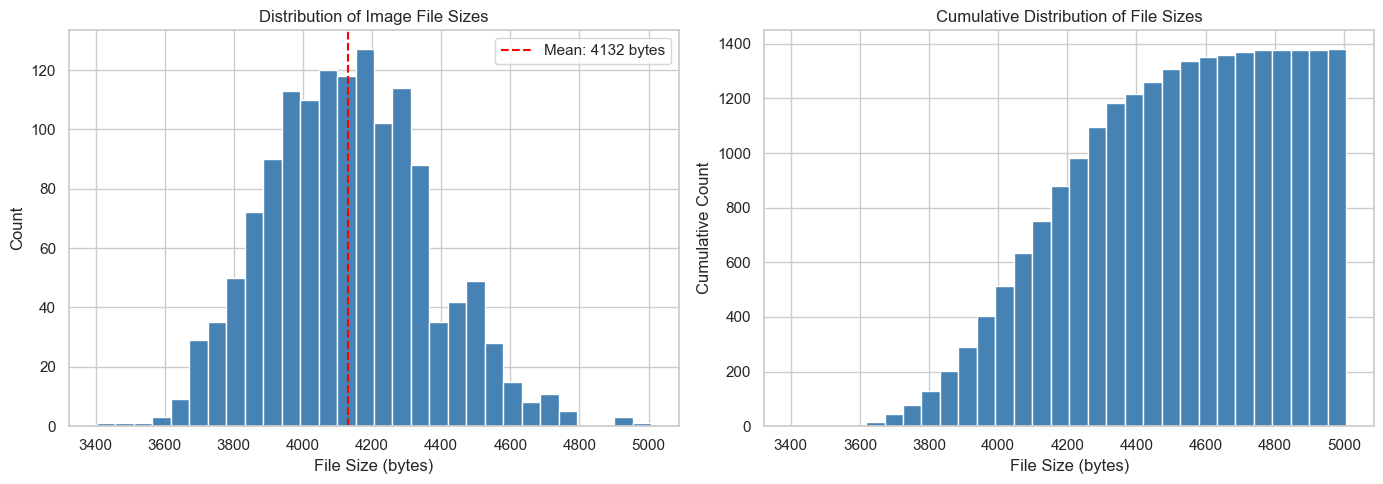

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(file_sizes, bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('File Size (bytes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Image File Sizes')
axes[0].axvline(np.mean(file_sizes), color='red', linestyle='--', label=f'Mean: {np.mean(file_sizes):.0f} bytes')
axes[0].legend()

axes[1].hist(file_sizes, bins=30, cumulative=True, color='steelblue', edgecolor='white')
axes[1].set_xlabel('File Size (bytes)')
axes[1].set_ylabel('Cumulative Count')
axes[1].set_title('Cumulative Distribution of File Sizes')

plt.tight_layout()
plt.savefig(BASE_DIR / 'dataset' / 'file_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample Image Visualization

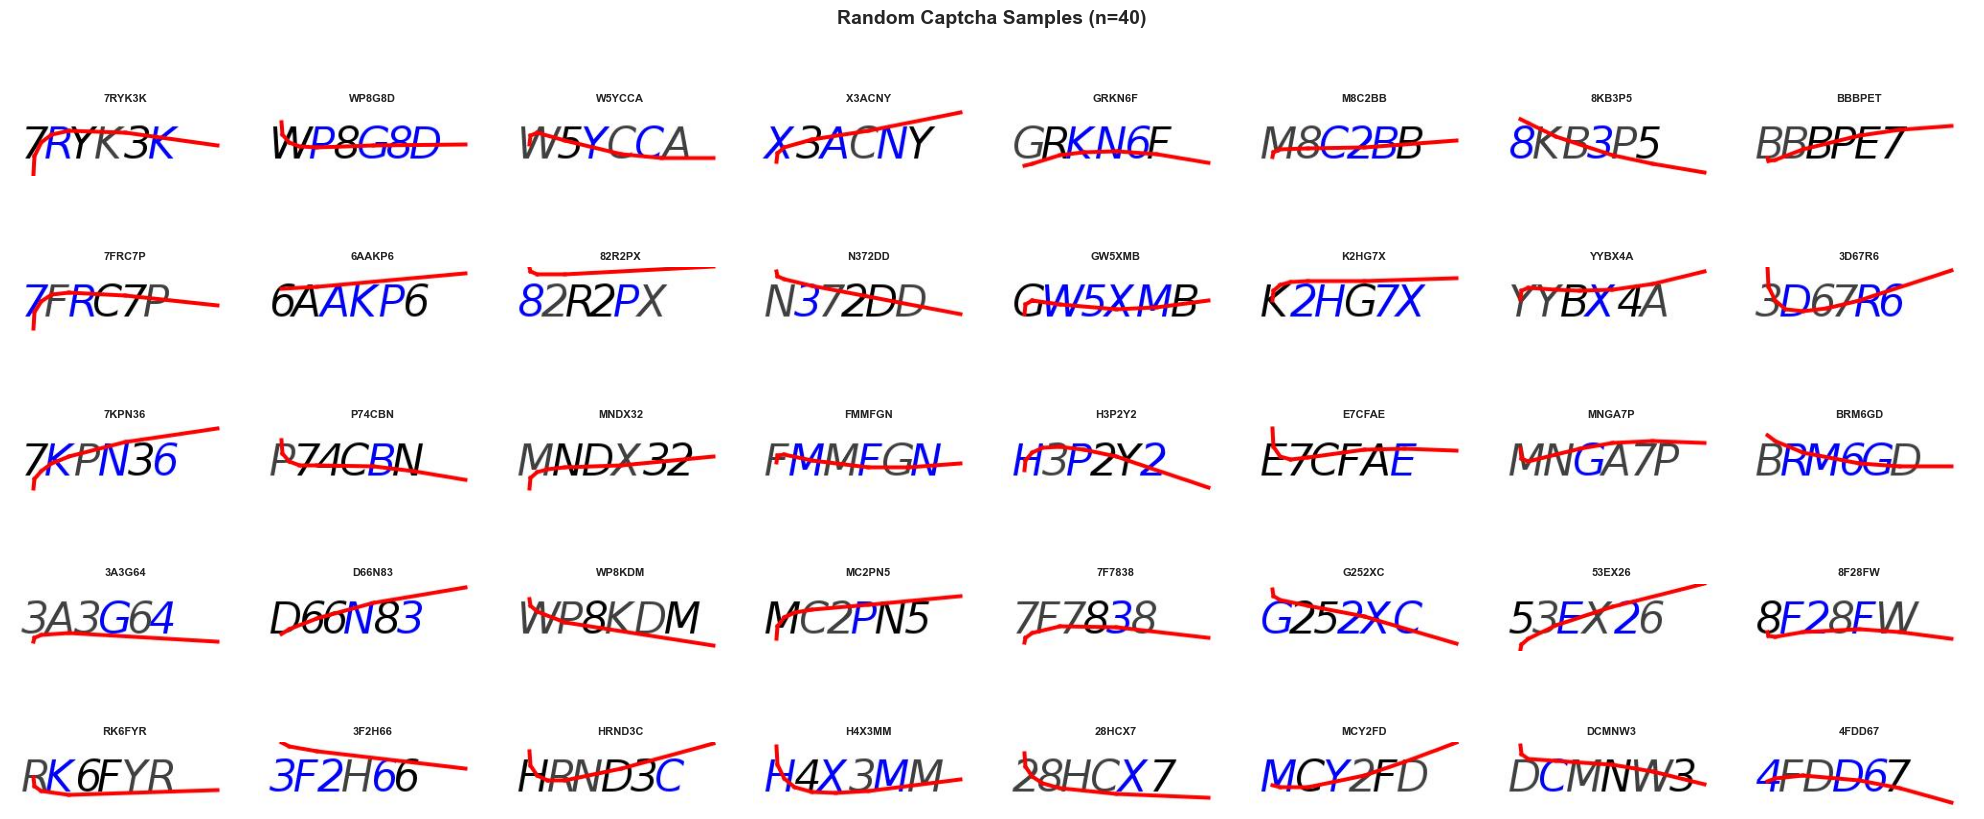

In [51]:
def show_captcha_samples(df, images_dir, n_rows=5, n_cols=8, seed=42):
    sample = df.sample(n=min(n_rows * n_cols, len(df)), random_state=seed)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 1.8))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, (i, row) in enumerate(sample.iterrows()):
        ax = axes[idx]
        img = Image.open(images_dir / row['image'])
        ax.imshow(img)
        ax.set_title(f"{row['captcha_value']}", fontsize=8, fontweight='bold')
        ax.axis('off')
    
    for idx in range(len(sample), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Random Captcha Samples (n={len(sample)})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'dataset' / 'sample_captchas.png', dpi=150, bbox_inches='tight')
    plt.show()

show_captcha_samples(df, IMAGES_DIR)

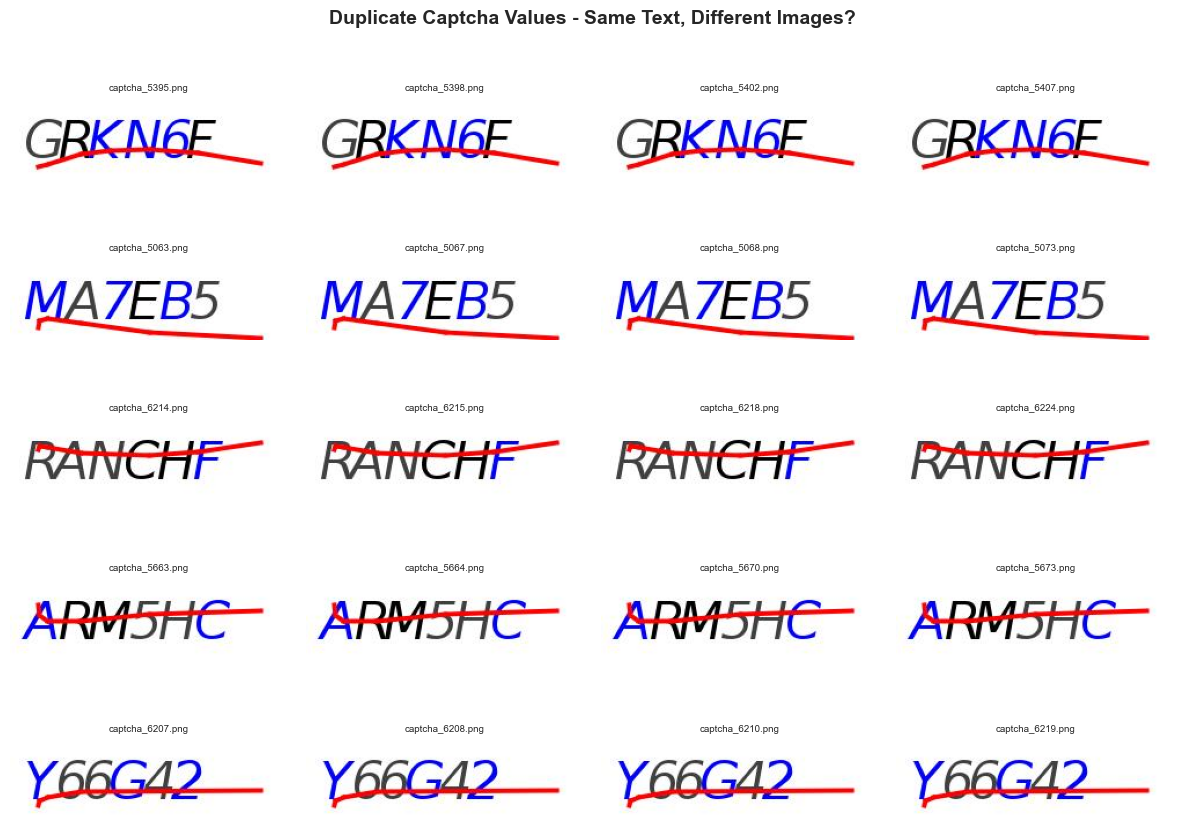

In [52]:
def show_duplicate_samples(df, images_dir, n_examples=5):
    value_counts = df['captcha_value'].value_counts()
    top_dupes = value_counts[value_counts > 1].head(n_examples).index.tolist()
    
    fig, axes = plt.subplots(len(top_dupes), 4, figsize=(12, len(top_dupes) * 1.8))
    if len(top_dupes) == 1:
        axes = axes.reshape(1, -1)
    
    for i, val in enumerate(top_dupes):
        matching = df[df['captcha_value'] == val].head(4)
        for j, (_, row) in enumerate(matching.iterrows()):
            img = Image.open(images_dir / row['image'])
            axes[i][j].imshow(img)
            axes[i][j].set_title(f"{row['image']}", fontsize=7)
            axes[i][j].axis('off')
        for j in range(len(matching), 4):
            axes[i][j].axis('off')
        
        axes[i][0].set_ylabel(val, fontsize=10, fontweight='bold', rotation=0, labelpad=50)
    
    plt.suptitle('Duplicate Captcha Values - Same Text, Different Images?', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE_DIR / 'dataset' / 'duplicate_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

show_duplicate_samples(df, IMAGES_DIR)

## 6. Summary & Key Insights

In [53]:
print('=' * 60)
print('DATASET SUMMARY')
print('=' * 60)
print(f"Total samples:              {len(df)}")
print(f"Unique captcha values:      {df['captcha_value'].nunique()}")
print(f"Duplicate values:           {(df['captcha_value'].value_counts() > 1).sum()}")
print(f"Max duplicate count:        {df['captcha_value'].value_counts().max()}")
print(f"Captcha lengths:            {sorted(df['captcha_length'].unique())}")
print(f"Dominant length:            {df['captcha_length'].mode().values[0]} ({(df['captcha_length'] == df['captcha_length'].mode().values[0]).sum()} samples)")
print(f"Unique characters:          {len(char_freq)}")
print(f"  Digits:                   {len(digits)} ({', '.join(digits)})")
print(f"  Letters:                  {len(letters)} ({', '.join(letters)})")
print(f"Image dimensions:           {unique_sizes}")
print(f"Color mode:                 {unique_modes}")
print(f"Image format:               {unique_formats}")
print(f"Avg file size:              {np.mean(file_sizes):.0f} bytes")
print('=' * 60)

DATASET SUMMARY
Total samples:              1380
Unique captcha values:      929
Duplicate values:           239
Max duplicate count:        6
Captcha lengths:            [5, 6, 7]
Dominant length:            6 (1369 samples)
Unique characters:          28
  Digits:                   7 (2, 3, 4, 5, 6, 7, 8)
  Letters:                  20 (A, B, C, D, E, F, G, H, K, M, N, P, R, S, T, V, W, X, Y, Z)
Image dimensions:           {(240, 70)}
Color mode:                 {'RGB'}
Image format:               {'JPEG'}
Avg file size:              4132 bytes


## 7. Cleaned Dataset: Drop Duplicates & Filter to 6 Characters

Keep only one row per unique captcha value (deduplicate) and only values with exactly 6 characters.

In [54]:
df_clean = df.drop_duplicates(subset='captcha_value', keep='first').copy()
df_clean = df_clean[df_clean['captcha_value'].str.len() == 6].copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"Original samples:     {len(df)}")
print(f"After dedup + len=6:  {len(df_clean)}")
print(f"Removed:              {len(df) - len(df_clean)}")
print(f"\nUnique captcha values: {df_clean['captcha_value'].nunique()}")
print(f"Duplicate values:       {(df_clean['captcha_value'].value_counts() > 1).sum()}")
print(f"\nAny null?")
print(df_clean.isnull().sum())

Original samples:     1380
After dedup + len=6:  922
Removed:              458

Unique captcha values: 922
Duplicate values:       0

Any null?
image             0
captcha_value     0
captcha_length    0
dtype: int64


### 7.1 Captcha Length Distribution

Length distribution:
  Length 6: 922 samples (100.00%)


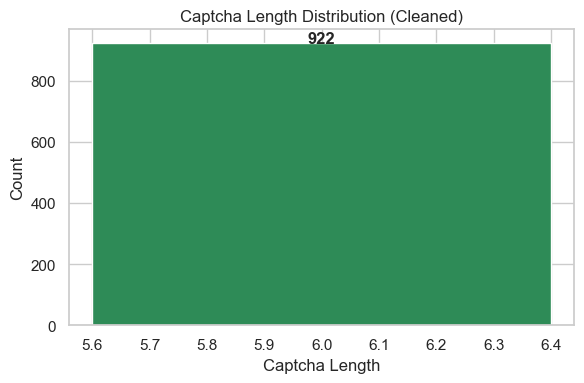

In [55]:
df_clean['captcha_length'] = df_clean['captcha_value'].str.len()
length_counts = df_clean['captcha_length'].value_counts().sort_index()

print(f"Length distribution:")
for length, count in length_counts.items():
    print(f"  Length {length}: {count} samples ({count/len(df_clean)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(length_counts.index, length_counts.values, color='seagreen')
ax.set_xlabel('Captcha Length')
ax.set_ylabel('Count')
ax.set_title('Captcha Length Distribution (Cleaned)')
for i, v in enumerate(length_counts.values):
    ax.text(length_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Character Frequency Analysis

In [56]:
all_chars_clean = ''.join(df_clean['captcha_value'].tolist())
char_freq_clean = Counter(all_chars_clean)

digits_clean = sorted([c for c in char_freq_clean if c.isdigit()])
letters_clean = sorted([c for c in char_freq_clean if c.isalpha()])

print(f"Total characters: {len(all_chars_clean)}")
print(f"Unique characters: {len(char_freq_clean)}")
print(f"Digits used ({len(digits_clean)}): {', '.join(digits_clean)}")
print(f"Letters used ({len(letters_clean)}): {', '.join(letters_clean)}")

Total characters: 5532
Unique characters: 26
Digits used (7): 2, 3, 4, 5, 6, 7, 8
Letters used (19): A, B, C, D, E, F, G, H, K, M, N, P, R, S, T, W, X, Y, Z


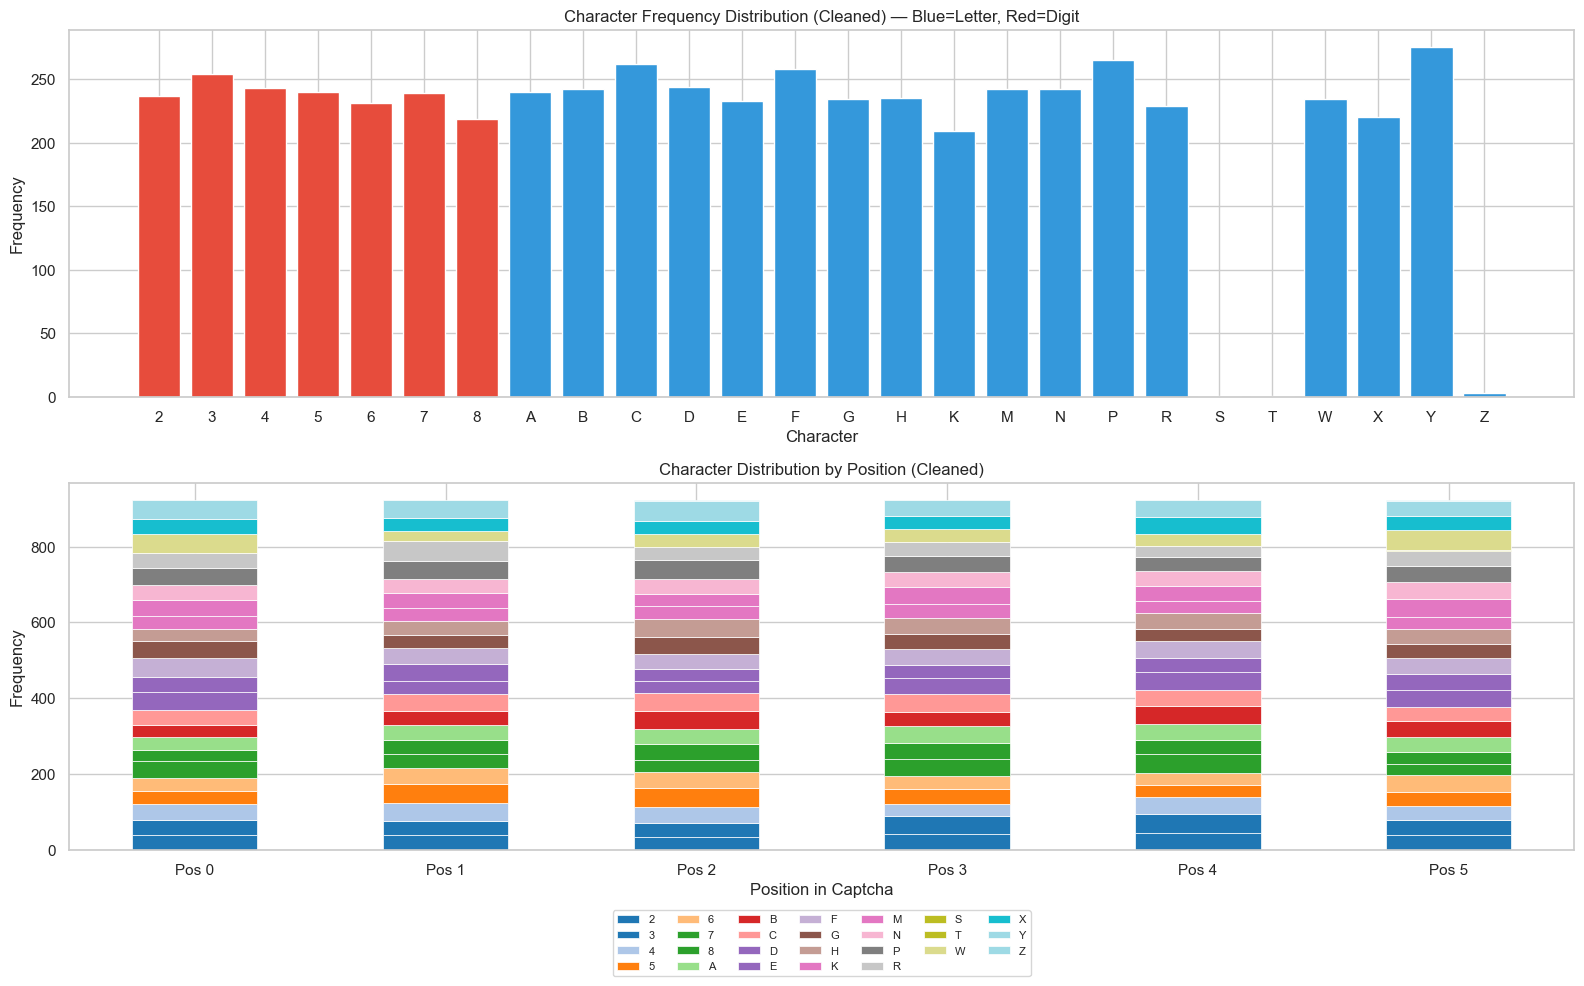

In [57]:
sorted_chars = sorted(char_freq_clean.items(), key=lambda x: x[0])
chars_list = [c for c, _ in sorted_chars]
freqs_list = [f for _, f in sorted_chars]
colors = ['#e74c3c' if c.isdigit() else '#3498db' for c in chars_list]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(chars_list, freqs_list, color=colors)
axes[0].set_xlabel('Character')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Character Frequency Distribution (Cleaned) — Blue=Letter, Red=Digit')

max_len = df_clean['captcha_length'].max()
position_chars = {}
for pos in range(max_len):
    pos_counter = Counter()
    for val in df_clean['captcha_value']:
        if pos < len(val):
            pos_counter[val[pos]] += 1
    position_chars[pos] = pos_counter

position_df = pd.DataFrame(position_chars).T.fillna(0)
position_df = position_df[sorted(position_df.columns)]

position_df.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab20', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Position in Captcha')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Character Distribution by Position (Cleaned)')
axes[1].legend(ncol=7, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15))
axes[1].set_xticklabels([f'Pos {i}' for i in range(max_len)], rotation=0)

plt.tight_layout()
plt.show()

### 7.3 Duplicate Captcha Values (verification)

In [58]:
value_counts_clean = df_clean['captcha_value'].value_counts()
dupes_clean = value_counts_clean[value_counts_clean > 1]

if len(dupes_clean) == 0:
    print("No duplicate captcha values remain.")
else:
    print(f"WARNING: {len(dupes_clean)} values still have duplicates.")
    print(dupes_clean.head(10))

No duplicate captcha values remain.


### 7.4 Image Property Analysis

In [59]:
clean_sizes = []
clean_modes = []
clean_file_sizes = []

for img_name in df_clean['image']:
    path = IMAGES_DIR / img_name
    im = Image.open(path)
    clean_sizes.append(im.size)
    clean_modes.append(im.mode)
    clean_file_sizes.append(os.path.getsize(path))
    im.close()

print(f"Image dimensions: {set(clean_sizes)}")
print(f"Color modes: {set(clean_modes)}")
print(f"\nFile size (bytes):")
print(f"  Min: {min(clean_file_sizes)}")
print(f"  Max: {max(clean_file_sizes)}")
print(f"  Mean: {np.mean(clean_file_sizes):.0f}")
print(f"  Median: {np.median(clean_file_sizes):.0f}")

Image dimensions: {(240, 70)}
Color modes: {'RGB'}

File size (bytes):
  Min: 3404
  Max: 5007
  Mean: 4131
  Median: 4124


### 7.5 Sample Image Visualization

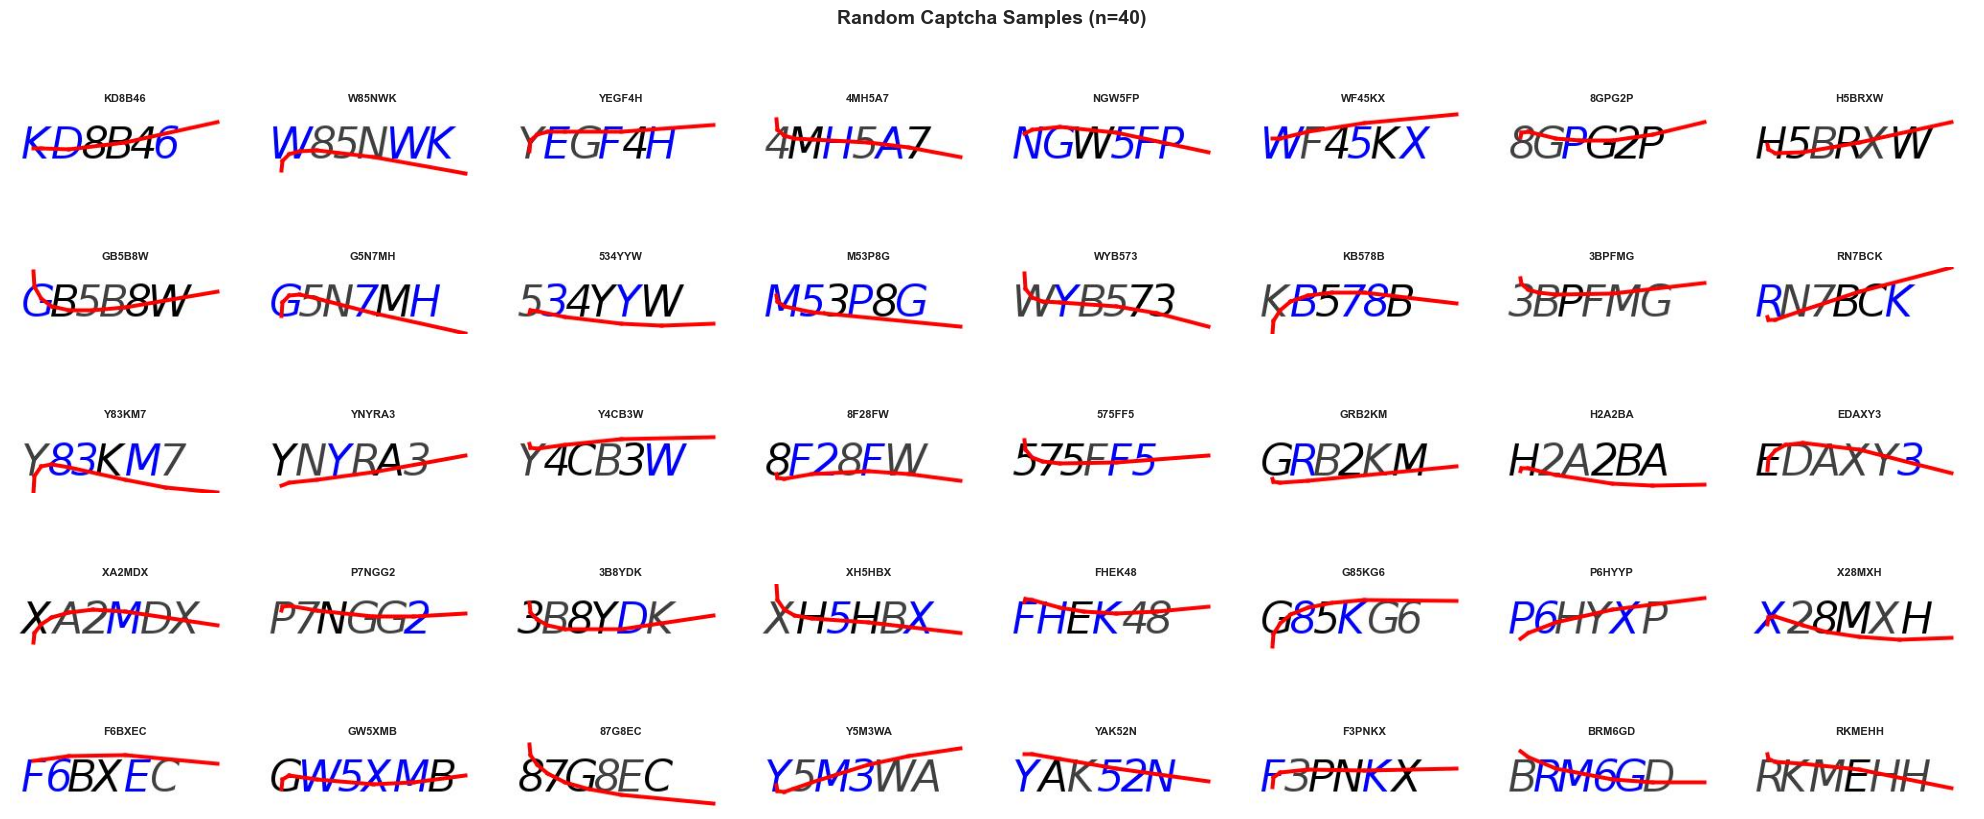

In [60]:
show_captcha_samples(df_clean, IMAGES_DIR)

### 7.6 Summary (Cleaned Dataset)

In [61]:
print('=' * 60)
print('CLEANED DATASET SUMMARY')
print('=' * 60)
print(f"Total samples:              {len(df_clean)}")
print(f"Unique captcha values:      {df_clean['captcha_value'].nunique()}")
print(f"Duplicate values:           {(df_clean['captcha_value'].value_counts() > 1).sum()}")
print(f"Unique characters:          {len(char_freq_clean)}")
print(f"  Digits:                   {len(digits_clean)} ({', '.join(digits_clean)})")
print(f"  Letters:                  {len(letters_clean)} ({', '.join(letters_clean)})")
print(f"Image dimensions:           {set(clean_sizes)}")
print(f"Color mode:                 {set(clean_modes)}")
print(f"Avg file size:              {np.mean(clean_file_sizes):.0f} bytes")
print('=' * 60)

CLEANED DATASET SUMMARY
Total samples:              922
Unique captcha values:      922
Duplicate values:           0
Unique characters:          26
  Digits:                   7 (2, 3, 4, 5, 6, 7, 8)
  Letters:                  19 (A, B, C, D, E, F, G, H, K, M, N, P, R, S, T, W, X, Y, Z)
Image dimensions:           {(240, 70)}
Color mode:                 {'RGB'}
Avg file size:              4131 bytes


## 8. Export Cleaned Dataset for Benchmarking

Save the cleaned dataset so `benchmark.py` can read it.

In [62]:
cleaned_path = DATASET_PATH.with_name('cleaned_ground_truth.csv')
df_clean.to_csv(cleaned_path, index=False)
print(f"Saved {len(df_clean)} samples to {cleaned_path}")

Saved 922 samples to /Users/alikhan/programming/Captcha-Benchmark-Tool/V2/dataset/cleaned_ground_truth.csv
